In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score, RocCurveDisplay
from google.colab import drive

#Carga y exploración inicial

In [ ]:
df = pd.read_csv("/content/TelcoClientesFuga.csv")
#df = pd.read_csv("/content/sample_data/TelcoClientesFuga.csv")
df.head(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7040 entries, 0 to 7039
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7040 non-null   object 
 1   gender            7040 non-null   object 
 2   SeniorCitizen     7040 non-null   int64  
 3   Partner           7040 non-null   object 
 4   Dependents        7040 non-null   object 
 5   tenure            7040 non-null   int64  
 6   PhoneService      7040 non-null   object 
 7   MultipleLines     7040 non-null   object 
 8   InternetService   7040 non-null   object 
 9   OnlineSecurity    7040 non-null   object 
 10  OnlineBackup      7040 non-null   object 
 11  DeviceProtection  7040 non-null   object 
 12  TechSupport       7040 non-null   object 
 13  StreamingTV       7040 non-null   object 
 14  StreamingMovies   7040 non-null   object 
 15  Contract          7040 non-null   object 
 16  PaperlessBilling  7040 non-null   object 


`TotalCharges` debería ser numérico

#Limpieza

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Volvemos a revisar y vemos 8 NAs en `TotalCharges` entocnes los revisamos.

In [ ]:
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges", 'Churn']]

,tenure,MonthlyCharges,TotalCharges,Churn
1079,0,25.75,NaN,No
1337,0,56.05,NaN,No
3328,0,19.85,NaN,No
3823,0,25.35,NaN,No
4377,0,20.00,NaN,No
5215,0,19.70,NaN,No
6667,0,73.35,NaN,No
6751,0,61.90,NaN,No


Se botan porque no aportan. Si la pregunta es ¿Quiénes están en riesgo de irse? Estos clientes no aportan nada porque no han tenido ni tiempo de irse.

In [ ]:
df = df.dropna()

Eliminamos `customerID` ya que no sirve para el análisis

In [ ]:
df = df.drop(columns=['customerID'])

Convertimos el target a 0s y 1s

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

#Exploración numérica

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
columnas = df[['MonthlyCharges','TotalCharges']]
estadisticas_descriptivas = columnas.describe()

print("Estadísticas descriptivas para las columnas:")
print(estadisticas_descriptivas)

Estadísticas descriptivas para las columnas:
       MonthlyCharges  TotalCharges
count     7032.000000   7032.000000
mean        64.798208   2283.300441
std         30.085974   2266.771362
min         18.250000     18.800000
25%         35.587500    401.450000
50%         70.350000   1397.475000
75%         89.862500   3794.737500
max        118.750000   8684.800000


In [ ]:
percent = df["Churn"].value_counts(normalize=True)
print(f"Porcentaje de clientes que se van: \n{percent}")

Porcentaje de clientes que se van: 
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [ ]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


In [ ]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),0.832685,0.167315
Credit card (automatic),0.847469,0.152531
Electronic check,0.547146,0.452854
Mailed check,0.807980,0.192020


In [ ]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index")

Churn,0,1
InternetService,,
DSL,0.810017,0.189983
Fiber optic,0.581072,0.418928
No,0.925658,0.074342


In [ ]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize="index")

Churn,0,1
TechSupport,,
No,0.583525,0.416475
No internet service,0.925658,0.074342
Yes,0.848039,0.151961


In [ ]:
pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize="index")

Churn,0,1
OnlineSecurity,,
No,0.582213,0.417787
No internet service,0.925658,0.074342
Yes,0.853598,0.146402


#Exploración gráfica

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

<Axes: xlabel='Churn', ylabel='tenure'>

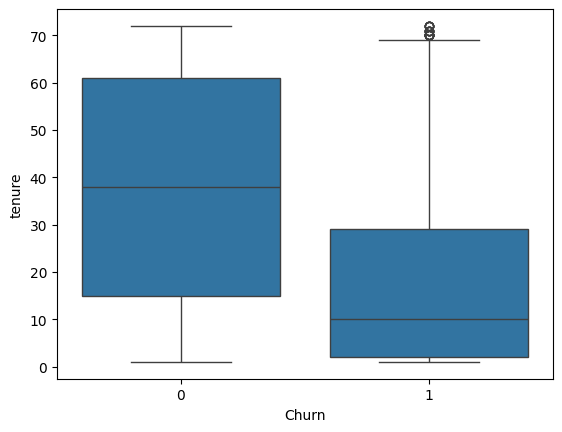

In [ ]:
sns.boxplot(x="Churn", y="tenure", data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

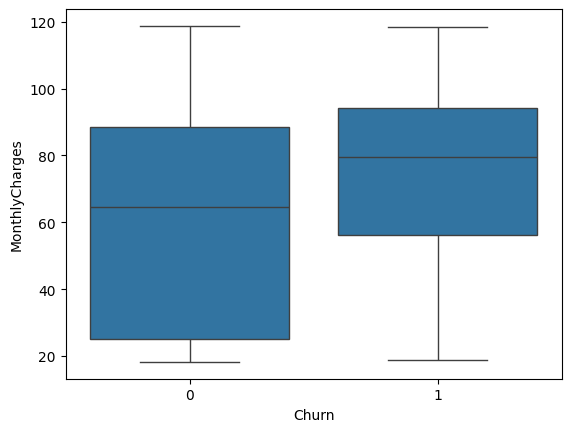

In [ ]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

<Axes: xlabel='Churn', ylabel='TotalCharges'>

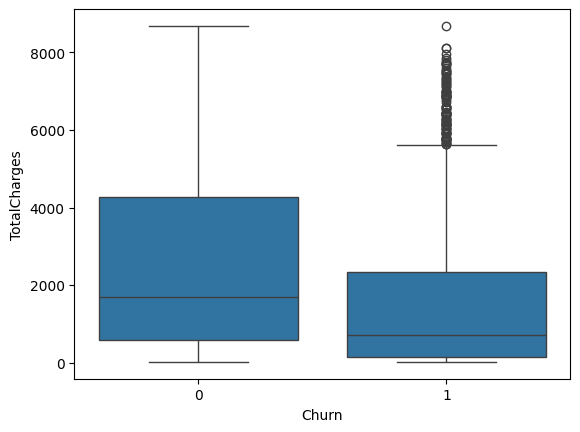

In [ ]:
sns.boxplot(x="Churn", y="TotalCharges", data=df)

<Axes: xlabel='Contract', ylabel='count'>

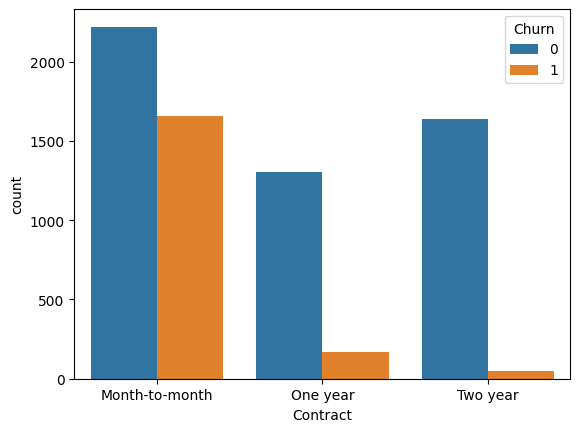

In [ ]:
sns.countplot(x="Contract", hue="Churn", data=df)

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

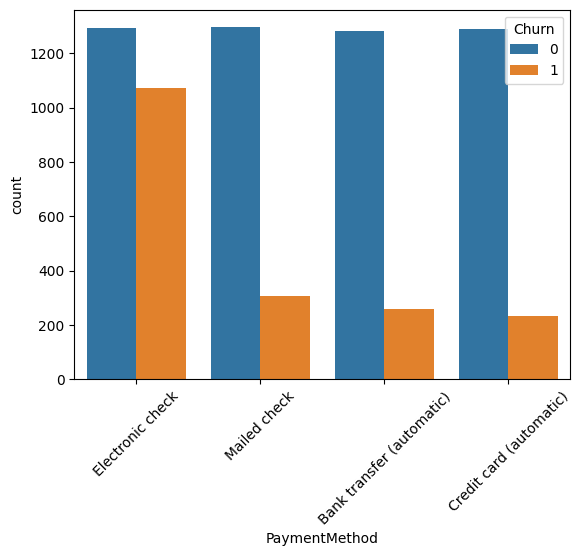

In [ ]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=45)

<Axes: xlabel='InternetService', ylabel='count'>

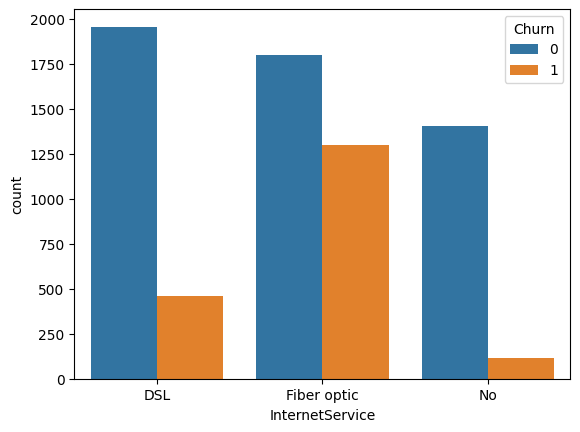

In [ ]:
sns.countplot(x="InternetService", hue="Churn", data=df)

<Axes: xlabel='TechSupport', ylabel='count'>

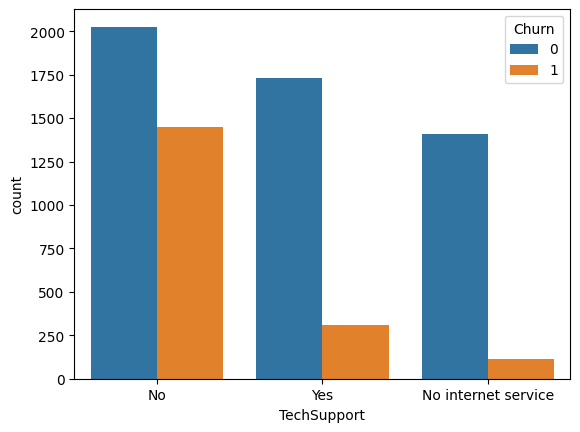

In [ ]:
sns.countplot(x="TechSupport", hue="Churn", data=df)

<Axes: xlabel='OnlineSecurity', ylabel='count'>

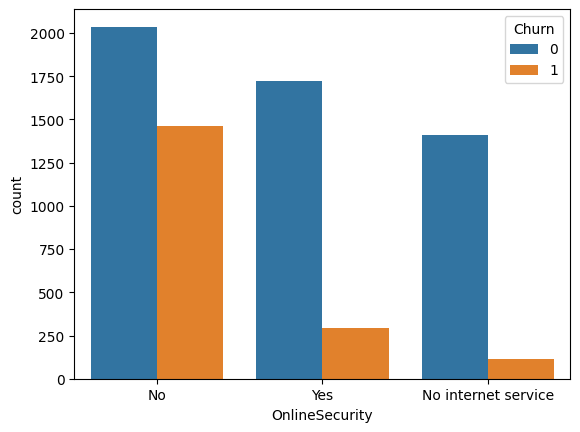

In [ ]:
sns.countplot(x="OnlineSecurity", hue="Churn", data=df)

#Modelado

##Dummies

Creamos dummies para futuro modelado

In [ ]:
categoricas = [
    'gender', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

df_dummies = pd.get_dummies(df, columns=categoricas, dtype=int, drop_first=True)
df_powerbi = pd.get_dummies(df, columns=categoricas, dtype=int)

df_dummies.head(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1


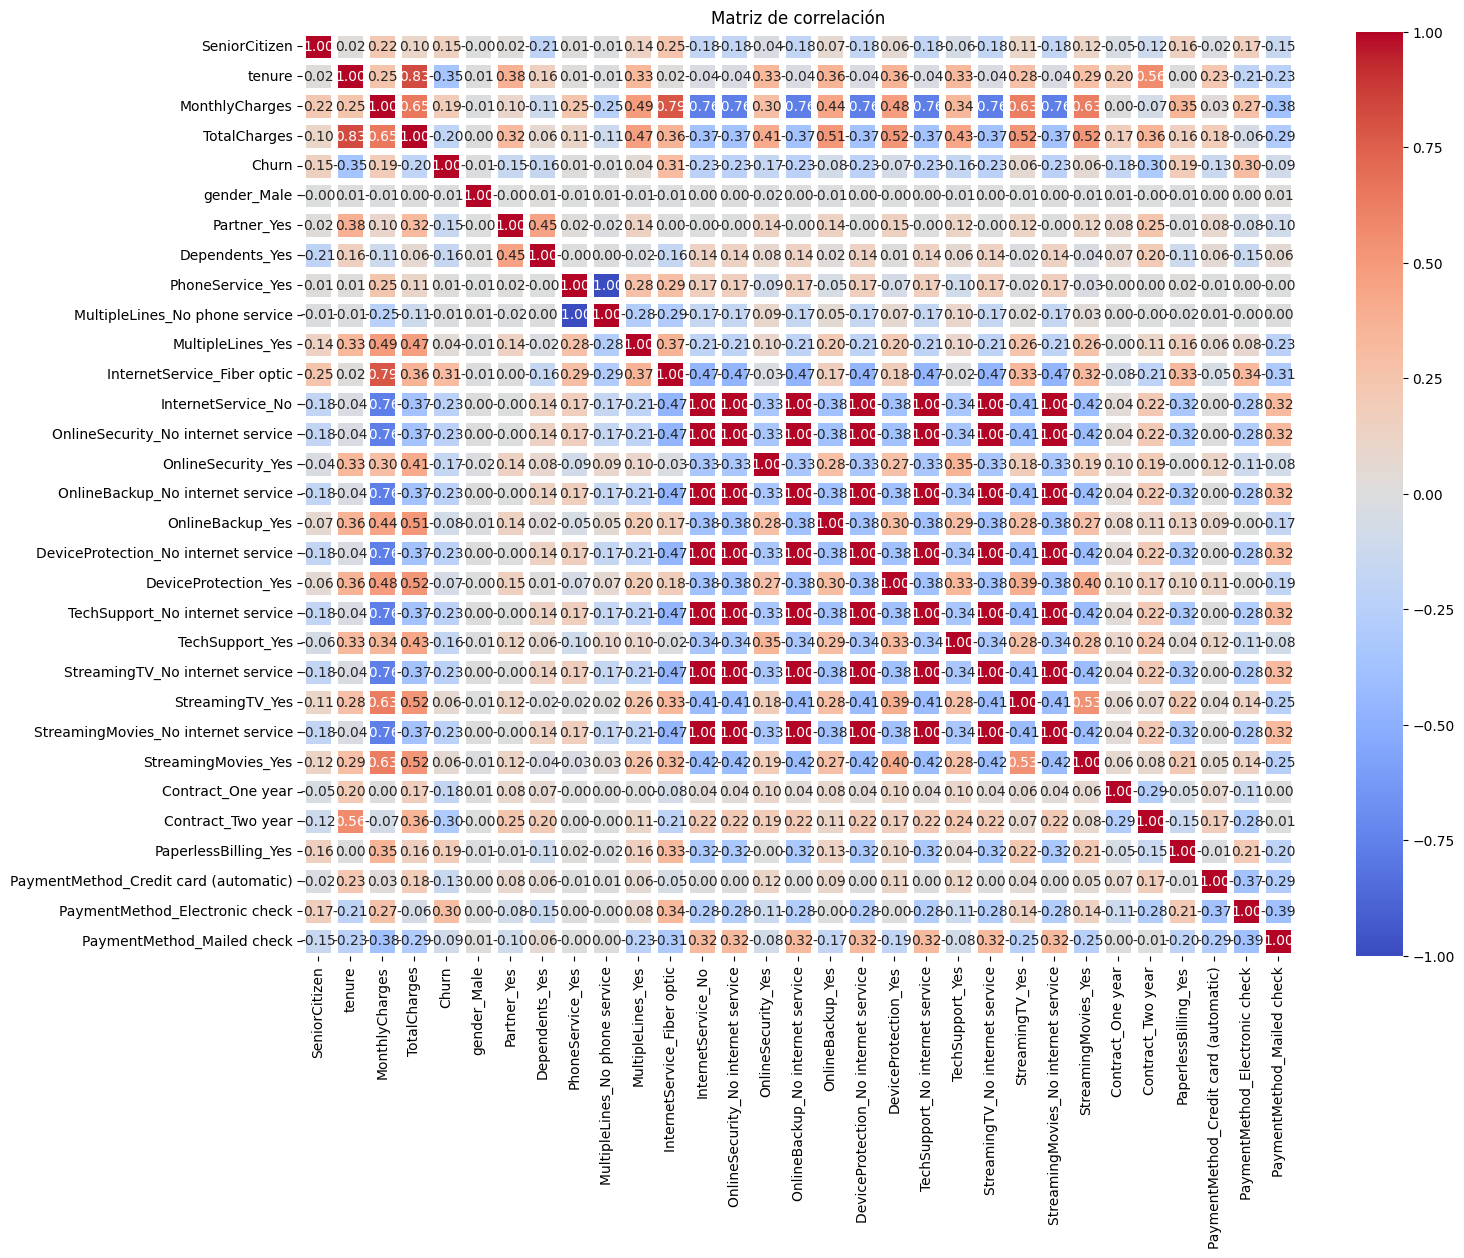

In [ ]:
#Calcular la matriz de correlación
matriz_correlacion = df_dummies.corr()

#Crear un mapa de calor
plt.figure(figsize=(16, 12))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidth=5)
plt.title("Matriz de correlación")
plt.show()

Mediante la matriz de correlación observamos posibles correlaciones entre variables. Algunas variables perfectamente correlacionadas describen lo mismo, por ejemplo las que explican no phone service. o Tenure (tiempo que el cliente tiene de estar con la empresa) y total charges (a mayor tiempo con la empresa mayores cargos totales).

##Convertir df limpio a csv

Aprovechamos que aquí generamos un dataset limpio para convertirlo a csv y usarlo en el análisis de power BI

In [ ]:
#df_powerbi.to_csv("telco_limpio.csv", index=False)

##Variables estadísticamente significativas

In [ ]:
df_dummies.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [ ]:
caracteristicas_columnas = [
    'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
    'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
    'MultipleLines_No phone service', 'MultipleLines_Yes',
    'InternetService_Fiber optic', 'InternetService_No',
    'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
    'OnlineBackup_No internet service', 'OnlineBackup_Yes',
    'DeviceProtection_No internet service', 'DeviceProtection_Yes',
    'TechSupport_No internet service', 'TechSupport_Yes',
    'StreamingTV_No internet service', 'StreamingTV_Yes',
    'StreamingMovies_No internet service', 'StreamingMovies_Yes',
    'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
    'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'
    ]

X = df_dummies[caracteristicas_columnas] #Independent variables
y = df_dummies['Churn'] #Target variable

In [ ]:
def regressionResults(remove_cols=None):
    X2 = X.copy()

    #Deja usar una lista o un str
    if remove_cols is not None:
        if isinstance(remove_cols, str):
            remove_cols = [remove_cols]
        X2 = X2.drop(columns=remove_cols, errors='ignore')

    #Entradas de la regresión
    X2 = sm.add_constant(X2).rename(columns={'const': 'intercept'})
    X2 = X2.apply(pd.to_numeric, errors='coerce')
    y2 = pd.to_numeric(y, errors='coerce')

    #Fit al modelo
    est = sm.OLS(y2, X2)
    est2 = est.fit()

    #Intervalo de confianza
    conf = est2.conf_int(alpha=0.05)

    print(est2.summary())   # OLS = Ordinary Least Squares

In [ ]:
regressionResults()

                            OLS Regression Results                            
Dep. Variable:                  Churn   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     120.9
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:17:19   Log-Likelihood:                -3057.9
No. Observations:                7032   AIC:                             6164.
Df Residuals:                    7008   BIC:                             6328.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [ ]:
#Eliminación directa de variables con valores p muy elevados e irrelevantes
regressionResults(['MonthlyCharges', 'gender_Male', 'Partner_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check', 'OnlineBackup_Yes', 'DeviceProtection_Yes'])

                            OLS Regression Results                            
Dep. Variable:                  Churn   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     173.7
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:17:19   Log-Likelihood:                -3059.4
No. Observations:                7032   AIC:                             6153.
Df Residuals:                    7015   BIC:                             6269.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


Factores que aumentan churn (coef positivo)
* SeniorCitizen
* Fiber optic
* PaperlessBilling
* Electronic check
* Multiple lines

Factores que reducen churn (coef negativo)
* tenure
* TotalCharges
* contratos largos (1 y 2 años)
* OnlineSecurity
* TechSupport

##Separación train/test

In [ ]:
X = X.drop(columns=['MonthlyCharges', 'gender_Male', 'Partner_Yes',
                    'PaymentMethod_Credit card (automatic)',
                    'PaymentMethod_Mailed check', 'OnlineBackup_Yes',
                    'DeviceProtection_Yes'], axis=1) #Independent variables

y = df['Churn'] #Target variable

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

##Estandarización

In [ ]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Entrenamiento

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

#Evaluación del modelo

Se usa el modelo para hacer predicciones

In [ ]:
y_pred = model.predict(X_test)

##Métricas de clasificación

In [ ]:
nombres_target = ["No fuga", "Fuga"]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=nombres_target))

Accuracy: 0.7995260663507109
              precision    recall  f1-score   support

     No fuga       0.84      0.90      0.87      1549
        Fuga       0.65      0.53      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.71      0.73      2110
weighted avg       0.79      0.80      0.79      2110



El modelo acierta cerca del 80% de las veces, sin embargo podemos ver que el modelo es mejor detectando clientes que no se van. Esto significa que varios clientes se van sin que el modelo lo pueda predecir.

In [ ]:
y_pred = y_pred.astype(int)

#Accuracy = (True positive + true negative)/Total predictions
#De todas las predicciones, cuántas fueron acertadas
accuracy_exactitud = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy_exactitud)

#Precisión = True positive / (True positive + false positive)
#De todas las veces que el modelo dijo "se va", ¿cuántas veces se fue?
precision = metrics.precision_score(y_test, y_pred)
print("Precision: ", precision)

#Sensibilidad = True positive / (True positive + False negative)
#De todos los clientes que se iban, ¿Cuántos detectó el modelo?
sensibilidad_recall = metrics.recall_score(y_test, y_pred)
print("Sensibilidad: ", sensibilidad_recall)

#Especificidad = True negative / (True negative + false positive)
#De todos los clientes que se quedan, ¿Cuántos detectó el modelo?
especificidad = metrics.recall_score(y_test, y_pred, pos_label=0)
print("Especificidad: ", especificidad)

#f1 = 2 * ((precisión * sensibilidad ) / (precision + sensibilidad))
f1_score = metrics.f1_score(y_test, y_pred)
print("F1 Score: ", f1_score)

print(f"\nDe todas las predicciones el {accuracy_exactitud*100:.2f}% fue acertado.")
print(f"De todas las veces que el modelo dijo \"se va\", el {precision*100:.2f}% fue acertado.")
print(f"De todos los clientes que se iban, el modelo detectó el {especificidad*100:.2f}%.")
print(f"De todos los clientes que se quedan, el modelo detectó el {accuracy_exactitud*100:.2f}%.")

Accuracy:  0.7995260663507109
Precision:  0.65
Sensibilidad:  0.5329768270944741
Especificidad:  0.8960619754680439
F1 Score:  0.5857002938295789

De todas las predicciones el 79.95% fue acertado.
De todas las veces que el modelo dijo "se va", el 65.00% fue acertado.
De todos los clientes que se iban, el modelo detectó el 89.61%.
De todos los clientes que se quedan, el modelo detectó el 79.95%.


* De todas las predicciones el 79.95% fue acertado.
* De todas las veces que el modelo dijo "se va", el 65.00% fue acertado.
* De todos los clientes que se iban, el modelo detectó el 89.61%.
* De todos los clientes que se quedan, el modelo detectó el 79.95%.

##Matriz de confusión

In [ ]:
matriz_confusion = confusion_matrix(y_test, y_pred)
matriz_confusion

array([[1388,  161],
       [ 262,  299]])

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

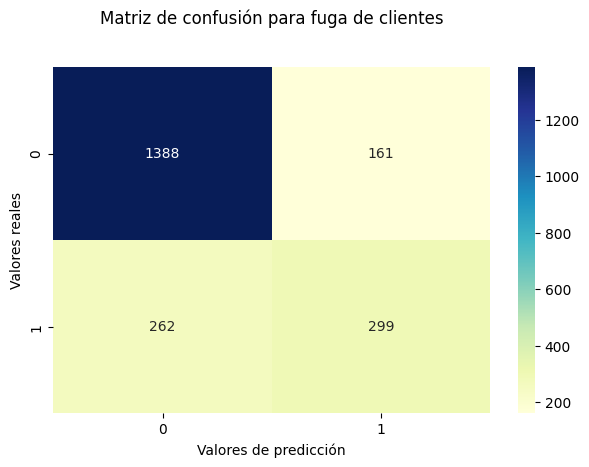

In [ ]:
nombres_clases = ['No churn', 'Churn']
fig, ax = plt.subplots(figsize=(6,4))
marcas_verificacion = np.arange(len(nombres_clases))

plt.xticks(marcas_verificacion, nombres_clases)
plt.yticks(marcas_verificacion, nombres_clases)

sns.heatmap(pd.DataFrame(matriz_confusion), annot=True, fmt="g", cmap="YlGnBu")

ax.xaxis.set_label_position("bottom")
plt.tight_layout()
plt.title("Matriz de confusión para fuga de clientes", y=1.1)
plt.ylabel("Valores reales")
plt.xlabel("Valores de predicción")
plt

* El modelo predijo que 1,388 personas no se irían, y en efecto, no se fueron. (1,1)
* El modelo predijo que 161 personas se irían, pero no se fueron. (1,2)
* El modelo predijo que 262 personas no se irían, pero sí se fueron. (2,1)
* El modelo predijo que 299 personas se irían, y en efecto se fueron. (2,2)

##Curva ROC

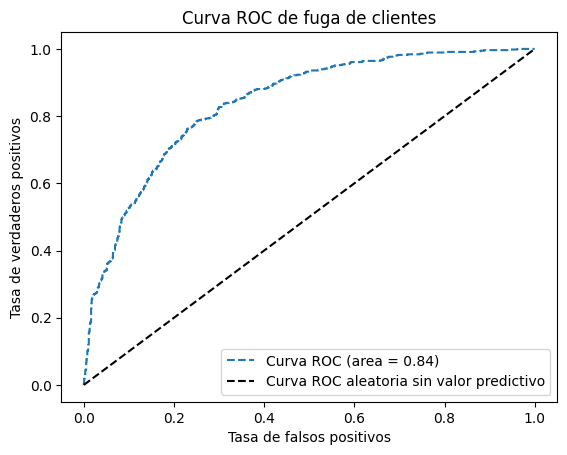

In [ ]:
ns_probs = [0 for _ in range(len(y_test))]
y_test = y_test.astype(int)

lr_probs = model.predict_proba(X_test)[::,1]
ns_fpr, ns_tpr, thresholds = roc_curve(y_test, ns_probs)
fpr, tpr, thresholds = roc_curve(y_test, lr_probs)

auc = roc_auc_score(y_test, lr_probs)
plt.plot(fpr, tpr, linestyle='--', label='Curva ROC (area = %0.2f)' % auc)
plt.plot([0,1], [0,1], 'k--', label="Curva ROC aleatoria sin valor predictivo")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title('Curva ROC de fuga de clientes')
plt.legend(loc=4)
plt.show()

La curva ROC muestra que el modelo tiene una buena capacidad para diferenciar entre clientes que abandonan y los que permanecen (AUC = 0.84). Sin embargo, aunque el modelo distingue bien, no identifica todos los casos de fuga.